In [ ]:
!nvidia-smi

Wed Mar 18 03:54:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **1. Introduction**

This notebook implements the full RLHF-style pipeline for Branch 2 of the project using open-source models, datasets, and training frameworks. The branch is based on HuggingFaceTB/SmolLM2-360M-Instruct as the base language model, yahma/alpaca-cleaned for supervised fine-tuning, and juyoungml/HelpSteer2-binarized as the open preference dataset for reward modelling and preference optimization. The purpose of the notebook is to build an instruction-following baseline, train a reward model from human preference data, apply Direct Preference Optimization (DPO) for alignment, and then evaluate the aligned model against the baseline.

In [ ]:
!pip -q install transformers datasets accelerate peft trl bitsandbytes sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.5 MB/s eta 0:00:00


In [ ]:
import torch
import transformers
import datasets
import trl
import peft

print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)
print("TRL version:", trl.__version__)
print("PEFT version:", peft.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Torch version: 2.10.0+cu128
Transformers version: 5.0.0
Datasets version: 4.0.0
TRL version: 0.29.0
PEFT version: 0.18.1
CUDA available: True
GPU name: Tesla T4


# **2. Environment Setup and Dataset Preparation**


This section establishes the computational environment required for the experiment by installing the necessary libraries and importing the modules used throughout the notebook. It then loads the instruction-following dataset (yahma/alpaca-cleaned) and the preference dataset (juyoungml/HelpSteer2-binarized) used in the later reward modelling and DPO stages. In addition, the tokenizer and configuration for HuggingFaceTB/SmolLM2-360M-Instruct are initialized so that all subsequent stages operate under a consistent experimental setting.

In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "HuggingFaceTB/SmolLM2-360M-Instruct"
PREF_DATASET_NAME = "juyoungml/HelpSteer2-binarized"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Model selected:", MODEL_NAME)
print("Preference dataset:", PREF_DATASET_NAME)
print("Pad token:", tokenizer.pad_token)
print("EOS token:", tokenizer.eos_token)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

Model selected: HuggingFaceTB/SmolLM2-360M-Instruct
Preference dataset: juyoungml/HelpSteer2-binarized
Pad token: <|im_end|>
EOS token: <|im_end|>


In [ ]:
from datasets import load_dataset

# Keep SFT dataset the same as Colab 1 for fairness
sft_raw = load_dataset("yahma/alpaca-cleaned", split="train[:5000]")

# New preference dataset for Colab 2
pref_train_raw = load_dataset(PREF_DATASET_NAME, split="train")
pref_eval_raw = load_dataset(PREF_DATASET_NAME, split="validation")

print("SFT rows:", len(sft_raw))
print("Reward/DPO train rows:", len(pref_train_raw))
print("Reward/DPO eval rows:", len(pref_eval_raw))
print(pref_train_raw[0])

README.md: 0.00B [00:00, ?B/s]

alpaca_data_cleaned.json:   0%|          | 0.00/44.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/51760 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/609 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/708k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7224 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/373 [00:00<?, ? examples/s]

SFT rows: 5000
Reward/DPO train rows: 7224
Reward/DPO eval rows: 373
{'prompt': '\n\nQuestion: \nIf I want to pick one signature appetizer to represent each Asian country, what do you suggest? and why？\n\nSingapore \nMalaysia\nIndonesia \nCambodia \nThailand\nThe Philippines \nVietnam\nGuam\nHawaii \nKorea \nJapan \nTaiwan \nMacau \nHong Kong \nChina\nIndia \nTurkey', 'chosen': 'Here are some suggestions for a signature appetizer from each Asian country:\n\nSingapore: Chili Crab Buns - a delicious combination of sweet and savory flavors, with a spicy kick from the chili crab sauce.\n\nMalaysia: Satay - grilled skewers of meat (usually chicken or beef) served with a delicious peanut sauce.\n\nIndonesia: Gado-Gado - a delicious salad made with boiled vegetables, served with a peanut sauce dressing.\n\nCambodia: Amok - a traditional Khmer curry, served in a coconut shell and made with fish, lemongrass, and other herbs and spices.\n\nThailand: Tom Yum Goong - a spicy and sour soup made wit

# **3. Baseline Model Development through Supervised Fine-Tuning**


This section develops the baseline instruction-following model through supervised fine-tuning (SFT). The Alpaca-cleaned dataset is reformatted into chat-style training examples to match the conversational structure expected by the selected base model. Parameter-efficient fine-tuning with LoRA is then applied in order to adapt the model with lower computational cost. The resulting adapter is saved as sft_smollm_adapter, and this model serves as the baseline reference for later comparison with the aligned model.

In [ ]:
def make_sft_text(example):
    user_text = example["instruction"].strip()

    if example["input"] and example["input"].strip():
        user_text += "\n\nInput:\n" + example["input"].strip()

    messages = [
        {"role": "system", "content": "You are a helpful AI assistant."},
        {"role": "user", "content": user_text},
        {"role": "assistant", "content": example["output"].strip()},
    ]

    return {
        "text": tokenizer.apply_chat_template(messages, tokenize=False)
    }

sft_dataset = sft_raw.map(
    make_sft_text,
    remove_columns=sft_raw.column_names
)

print(sft_dataset[0]["text"][:700])
print("Processed SFT rows:", len(sft_dataset))

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

<|im_start|>system
You are a helpful AI assistant.<|im_end|>
<|im_start|>user
Give three tips for staying healthy.<|im_end|>
<|im_start|>assistant
1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.

2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.

3. Get enough sleep: Getting enough qu
Processed SFT rows: 5000


# **4. Reward Model Construction from Preference Data**

This section constructs the reward model using pairwise preference data. The HelpSteer2-binarized dataset is processed into chosen and rejected response pairs so that the model can learn which outputs are preferred for a given prompt. A sequence-classification reward model is then trained and saved as reward_smollm. This stage is essential because it provides the learned preference signal that is later used in the evaluation of baseline and aligned model responses

In [ ]:
from peft import LoraConfig

sft_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

print("LoRA config ready.")

LoRA config ready.


In [ ]:
from trl import SFTTrainer, SFTConfig

sft_args = SFTConfig(
    output_dir="sft_smollm_adapter",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=2e-4,
    logging_steps=20,
    save_strategy="no",
    report_to="none",
    fp16=True,
    max_length=512,
    packing=False,
)
print("SFT config ready.")

SFT config ready.


In [ ]:
import gc
import torch

gc.collect()
torch.cuda.empty_cache()

sft_trainer = SFTTrainer(
    model=MODEL_NAME,
    args=sft_args,
    train_dataset=sft_dataset,
    processing_class=tokenizer,
    peft_config=sft_peft_config,
)

sft_train_result = sft_trainer.train()
print(sft_train_result)

model.safetensors:   0%|          | 0.00/724M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Adding EOS to train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/5000 [00:00<?, ? examples/s]

Step,Training Loss
20,1.378626
40,1.306661
60,1.311753
80,1.425149
100,1.213581
120,1.176706
140,1.265339
160,1.193388
180,1.170683
200,1.224919


TrainOutput(global_step=625, training_loss=1.2622363166809083, metrics={'train_runtime': 1385.7404, 'train_samples_per_second': 3.608, 'train_steps_per_second': 0.451, 'total_flos': 2371925433638400.0, 'train_loss': 1.2622363166809083})


In [ ]:
sft_trainer.model.save_pretrained("sft_smollm_adapter")
tokenizer.save_pretrained("sft_smollm_adapter")
print("Saved SFT adapter to sft_smollm_adapter")

Saved SFT adapter to sft_smollm_adapter


In [ ]:
from transformers import AutoModelForCausalLM
from peft import PeftModel

gc.collect()
torch.cuda.empty_cache()

sft_base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

sft_model = PeftModel.from_pretrained(sft_base_model, "sft_smollm_adapter")

messages = [
    {"role": "system", "content": "You are a helpful AI assistant."},
    {"role": "user", "content": "Explain reinforcement learning from human feedback in 3 simple sentences."}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = tokenizer(text, return_tensors="pt").to(sft_model.device)

with torch.no_grad():
    outputs = sft_model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=True,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id
    )

generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
response = tokenizer.decode(generated_ids, skip_special_tokens=True)
print(response)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Reinforcement learning is a type of artificial intelligence where a machine learns through trial and error interacting with the environment and receiving feedback in the form of rewards or penalties. This allows the machine to refine its behavior making it capable of adapting to new situations continuously and improving its decision-making processes based on that feedback.


In [ ]:
def build_reward_example(example):
    prompt_text = example["prompt"].strip()
    chosen_text = example["chosen"].strip()
    rejected_text = example["rejected"].strip()

    return {
        "chosen": tokenizer.apply_chat_template(
            [
                {"role": "user", "content": prompt_text},
                {"role": "assistant", "content": chosen_text},
            ],
            tokenize=False
        ),
        "rejected": tokenizer.apply_chat_template(
            [
                {"role": "user", "content": prompt_text},
                {"role": "assistant", "content": rejected_text},
            ],
            tokenize=False
        ),
    }

rm_train = pref_train_raw.map(
    build_reward_example,
    remove_columns=pref_train_raw.column_names
)

rm_eval = pref_eval_raw.map(
    build_reward_example,
    remove_columns=pref_eval_raw.column_names
)

print(rm_train.column_names)
print(rm_train[0])
print("Reward train rows:", len(rm_train))
print("Reward eval rows:", len(rm_eval))

Map:   0%|          | 0/7224 [00:00<?, ? examples/s]

Map:   0%|          | 0/373 [00:00<?, ? examples/s]

['chosen', 'rejected']
{'chosen': '<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nQuestion: \nIf I want to pick one signature appetizer to represent each Asian country, what do you suggest? and why？\n\nSingapore \nMalaysia\nIndonesia \nCambodia \nThailand\nThe Philippines \nVietnam\nGuam\nHawaii \nKorea \nJapan \nTaiwan \nMacau \nHong Kong \nChina\nIndia \nTurkey<|im_end|>\n<|im_start|>assistant\nHere are some suggestions for a signature appetizer from each Asian country:\n\nSingapore: Chili Crab Buns - a delicious combination of sweet and savory flavors, with a spicy kick from the chili crab sauce.\n\nMalaysia: Satay - grilled skewers of meat (usually chicken or beef) served with a delicious peanut sauce.\n\nIndonesia: Gado-Gado - a delicious salad made with boiled vegetables, served with a peanut sauce dressing.\n\nCambodia: Amok - a traditional Khmer curry, served in a coconut shell and made with fish, lemongrass

In [ ]:
import gc
import torch

for var_name in ["sft_model", "sft_base_model"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
torch.cuda.empty_cache()
print("Cleared SFT test model from memory.")

Cleared SFT test model from memory.


# **5. Qualitative Evaluation and Proxy Preference Testing**

Description:
This section evaluates the baseline and aligned models through direct output comparison and held-out proxy preference testing. First, selected prompts are used to compare SFT and DPO responses in order to observe differences in response quality, refusal behaviour, and overall usefulness. After that, a held-out subset of preference prompts is used for automatic proxy evaluation: both models generate responses, the trained reward model scores them, and the notebook computes the main comparison metrics, including DPO win rate, SFT win rate, tie rate, average reward score, and average reward margin.

In [ ]:
from transformers import AutoModelForSequenceClassification
from trl import RewardTrainer, RewardConfig

reward_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    device_map="auto"
)
reward_model.config.pad_token_id = tokenizer.pad_token_id

rm_args = RewardConfig(
    output_dir="reward_smollm",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=1,
    learning_rate=1e-5,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="no",
    report_to="none",
    fp16=False,
    max_length=512,
)

reward_trainer = RewardTrainer(
    model=reward_model,
    args=rm_args,
    train_dataset=rm_train,
    eval_dataset=rm_eval,
    processing_class=tokenizer,
)

print("Reward trainer ready.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

LlamaForSequenceClassification LOAD REPORT from: HuggingFaceTB/SmolLM2-360M-Instruct
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Adding EOS to train dataset:   0%|          | 0/7224 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7224 [00:00<?, ? examples/s]

Filtering train >512 tokens:   0%|          | 0/7224 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/373 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/373 [00:00<?, ? examples/s]

Filtering eval >512 tokens:   0%|          | 0/373 [00:00<?, ? examples/s]

Reward trainer ready.


In [ ]:
rm_train_result = reward_trainer.train()
print(rm_train_result)

Step,Training Loss,Validation Loss
100,0.722808,0.698943
200,0.699815,0.697593
300,0.695483,0.694781
400,0.705666,0.693985
500,0.695984,0.694198
600,0.701997,0.693523
700,0.697540,0.693311
800,0.697989,0.694218


TrainOutput(global_step=823, training_loss=0.6940915651193945, metrics={'train_runtime': 3057.2305, 'train_samples_per_second': 1.076, 'train_steps_per_second': 0.269, 'total_flos': 4336855472770560.0, 'train_loss': 0.6940915651193945})


In [ ]:
reward_trainer.model.save_pretrained("reward_smollm")
tokenizer.save_pretrained("reward_smollm")
print("Saved reward model to reward_smollm")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved reward model to reward_smollm


In [ ]:
import gc
import torch

for var_name in ["reward_model", "reward_trainer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()
torch.cuda.empty_cache()
print("Cleared reward-model objects.")

Cleared reward-model objects.


In [ ]:
from transformers import AutoModelForCausalLM
from peft import PeftModel

base_for_merge = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16
)

sft_merged_model = PeftModel.from_pretrained(
    base_for_merge,
    "sft_smollm_adapter"
).merge_and_unload()

sft_merged_model.save_pretrained("sft_smollm_merged")
tokenizer.save_pretrained("sft_smollm_merged")

del base_for_merge, sft_merged_model
gc.collect()
torch.cuda.empty_cache()

print("Saved merged SFT model to sft_smollm_merged")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved merged SFT model to sft_smollm_merged


In [ ]:
def build_dpo_example(example):
    prompt_text = example["prompt"].strip()
    chosen_text = example["chosen"].strip()
    rejected_text = example["rejected"].strip()

    return {
        "prompt": [{"role": "user", "content": prompt_text}],
        "chosen": [{"role": "assistant", "content": chosen_text}],
        "rejected": [{"role": "assistant", "content": rejected_text}],
    }

dpo_train = pref_train_raw.map(
    build_dpo_example,
    remove_columns=pref_train_raw.column_names
)

dpo_eval = pref_eval_raw.map(
    build_dpo_example,
    remove_columns=pref_eval_raw.column_names
)

print(dpo_train.column_names)
print(dpo_train[0])
print("DPO train rows:", len(dpo_train))
print("DPO eval rows:", len(dpo_eval))

Map:   0%|          | 0/7224 [00:00<?, ? examples/s]

Map:   0%|          | 0/373 [00:00<?, ? examples/s]

['prompt', 'chosen', 'rejected']
{'prompt': [{'content': 'Question: \nIf I want to pick one signature appetizer to represent each Asian country, what do you suggest? and why？\n\nSingapore \nMalaysia\nIndonesia \nCambodia \nThailand\nThe Philippines \nVietnam\nGuam\nHawaii \nKorea \nJapan \nTaiwan \nMacau \nHong Kong \nChina\nIndia \nTurkey', 'role': 'user'}], 'chosen': [{'content': 'Here are some suggestions for a signature appetizer from each Asian country:\n\nSingapore: Chili Crab Buns - a delicious combination of sweet and savory flavors, with a spicy kick from the chili crab sauce.\n\nMalaysia: Satay - grilled skewers of meat (usually chicken or beef) served with a delicious peanut sauce.\n\nIndonesia: Gado-Gado - a delicious salad made with boiled vegetables, served with a peanut sauce dressing.\n\nCambodia: Amok - a traditional Khmer curry, served in a coconut shell and made with fish, lemongrass, and other herbs and spices.\n\nThailand: Tom Yum Goong - a spicy and sour soup made

In [ ]:
from peft import LoraConfig

dpo_peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

print("DPO LoRA config ready.")

DPO LoRA config ready.


In [ ]:
from trl import DPOTrainer, DPOConfig

dpo_args = DPOConfig(
    output_dir="dpo_smollm",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    num_train_epochs=1,
    learning_rate=1e-5,
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="no",
    report_to="none",
    fp16=True,
    beta=0.1,
    max_length=512,
)

print("DPO config ready.")

DPO config ready.


In [ ]:
gc.collect()
torch.cuda.empty_cache()

dpo_trainer = DPOTrainer(
    model="sft_smollm_merged",
    args=dpo_args,
    train_dataset=dpo_train,
    eval_dataset=dpo_eval,
    processing_class=tokenizer,
    peft_config=dpo_peft_config,
)

print("DPO trainer ready.")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/7224 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/373 [00:00<?, ? examples/s]

DPO trainer ready.


In [ ]:
dpo_train_result = dpo_trainer.train()
print(dpo_train_result)

Step,Training Loss,Validation Loss
100,0.692467,0.692041
200,0.688227,0.689754
300,0.685098,0.687786
400,0.686653,0.686084
500,0.689027,0.684972
600,0.681689,0.683251
700,0.685892,0.682555
800,0.676781,0.681687
900,0.670377,0.681515


TrainOutput(global_step=903, training_loss=0.6857833698606438, metrics={'train_runtime': 5941.316, 'train_samples_per_second': 1.216, 'train_steps_per_second': 0.152, 'total_flos': 1.6940260289376e+16, 'train_loss': 0.6857833698606438})


In [ ]:
dpo_trainer.model.save_pretrained("dpo_smollm")
tokenizer.save_pretrained("dpo_smollm")
print("Saved DPO model to dpo_smollm")

Saved DPO model to dpo_smollm


# **6. Qualitative Evaluation and Proxy Preference Testing Part 2**


This section evaluates the baseline and aligned models through direct output comparison and held-out proxy preference testing. First, selected prompts are used to compare SFT and DPO responses in order to observe differences in response quality, refusal behaviour, and overall usefulness. After that, a held-out subset of preference prompts is used for automatic proxy evaluation: both models generate responses, the trained reward model scores them, and the notebook computes the main comparison metrics, including DPO win rate, SFT win rate, tie rate, average reward score, and average reward margin.

In [44]:
import gc
import torch
from transformers import AutoModelForCausalLM

gc.collect()
torch.cuda.empty_cache()

sft_compare_model = AutoModelForCausalLM.from_pretrained(
    "sft_smollm_merged",
    torch_dtype=torch.float16,
    device_map="auto"
)

dpo_compare_model = AutoModelForCausalLM.from_pretrained(
    "dpo_smollm",
    torch_dtype=torch.float16,
    device_map="auto"
)

eval_prompts = [
    "Explain reinforcement learning from human feedback in simple words.",
    "Write a polite refusal to an unsafe request.",
    "Give me three tips for managing study time."
]

def generate_answer(model_obj, prompt):
    messages = [
        {"role": "system", "content": "You are a helpful AI assistant."},
        {"role": "user", "content": prompt},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model_obj.device)

    with torch.no_grad():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=120,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True)

for p in eval_prompts:
    print("=" * 100)
    print("PROMPT:", p)
    print("\n--- SFT ---")
    print(generate_answer(sft_compare_model, p))
    print("\n--- DPO ---")
    print(generate_answer(dpo_compare_model, p))
    print()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

PROMPT: Explain reinforcement learning from human feedback in simple words.

--- SFT ---
Reinforcement learning is a type of machine learning where an algorithm learns by interacting with an environment in which it receives feedback in the form of rewards or penalties. This feedback tells the algorithm whether it's doing something right or not. For example, imagine you are a driver trying to avoid accidents on a road. Whenever you take a wrong turn and the car's system makes a mistake, you get a negative feedback. Over time, you adjust your routes and learn a new pattern to improve your chances of avoiding accidents. In the same way, in reinforcement learning, the algorithm continues to make decisions and learns

--- DPO ---
Imagine you have a robot or an assistant that wants to do some task, but it only succeeds every time it receives perfect feedback right from its creator. Sounds like something out of a movie, right? That's basically what reinforcement learning is all about.

Imagin

In [ ]:
eval_subset = pref_eval_raw.select(range(50))

def normalize_prompt(prompt):
    if isinstance(prompt, list):
        return prompt
    elif isinstance(prompt, str):
        return [{"role": "user", "content": prompt.strip()}]
    else:
        raise TypeError(f"Unexpected prompt type: {type(prompt)}")

eval_items = [{"prompt": normalize_prompt(x["prompt"])} for x in eval_subset]

print("Eval prompts:", len(eval_items))
print(eval_items[0])

Eval prompts: 50
{'prompt': [{'role': 'user', 'content': 'Is it possible to host data on a satellite?\n<extra_id_1>Assistant\nYes, it’s possible to host data on a satellite. Satellites can carry computer servers and other electronic equipment, so it’s possible to store and transmit data via satellite. This is often used for remote data storage and backup, as well as for internet and telecommunications services. Satellite-hosted data is relatively secure, as it’s not vulnerable to terrestrial threats like natural disasters or hacking, and it can be accessed from anywhere on the globe.\n<extra_id_1>User\nDoes hosting data on a satellite ensure that governments and corporations will be unable to acess the servers?\n<extra_id_1>Assistant\nHosting data on a satellite does help ensure privacy and security, as satellite data hosting services are often located in jurisdictions with strong privacy laws, and are physically isolated from terrestrial threats like hacking and natural disasters. How

In [ ]:
import gc
import torch
from transformers import AutoModelForCausalLM

gc.collect()
torch.cuda.empty_cache()

sft_eval_model = AutoModelForCausalLM.from_pretrained(
    "sft_smollm_merged",
    torch_dtype=torch.float16,
    device_map="auto"
)

def generate_from_prompt(model_obj, prompt_msgs):
    text = tokenizer.apply_chat_template(
        prompt_msgs,
        tokenize=False,
        add_generation_prompt=True
    )
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=256
    ).to(model_obj.device)

    with torch.no_grad():
        outputs = model_obj.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=True,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = outputs[0][inputs["input_ids"].shape[1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()

sft_outputs = []
for item in eval_items:
    sft_outputs.append(generate_from_prompt(sft_eval_model, item["prompt"]))

print(sft_outputs[0])

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

, it would depend on the specific service provider, the type of data being hosted, and the geographical location of the server.


In [ ]:
del sft_eval_model
gc.collect()
torch.cuda.empty_cache()

dpo_eval_model = AutoModelForCausalLM.from_pretrained(
    "dpo_smollm",
    torch_dtype=torch.float16,
    device_map="auto"
)

dpo_outputs = []
for item in eval_items:
    dpo_outputs.append(generate_from_prompt(dpo_eval_model, item["prompt"]))

print(dpo_outputs[0])

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/448 [00:00<?, ?it/s]

, the lack of physical boundaries between the satellite and the internet also means that there is still some risk of data being accessed by unauthorized individuals.


In [ ]:
del dpo_eval_model
gc.collect()
torch.cuda.empty_cache()

from transformers import AutoModelForSequenceClassification

reward_eval_model = AutoModelForSequenceClassification.from_pretrained(
    "reward_smollm",
    device_map="auto"
)
reward_eval_model.config.pad_token_id = tokenizer.pad_token_id

print("Reward model loaded.")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Reward model loaded.


# **7. Overall Result Summarisation and Visual Analysis**


This final section organizes the outputs of the evaluation stages into a form suitable for reporting and presentation. It saves the main result files, including proxy_preference_eval.csv and evaluation_summary.csv, and generates the visualizations used in the final analysis, such as win-count plots, average reward score comparisons, reward margin distributions, and scatter plots. This section therefore serves as the final evidence-producing stage of the notebook and supports the results discussed in the report and presentation. It also give comparasions of previous branch and present branch

In [40]:
def score_response(prompt_msgs, response_text):
    full_msgs = prompt_msgs + [{"role": "assistant", "content": response_text}]
    text = tokenizer.apply_chat_template(full_msgs, tokenize=False)
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(reward_eval_model.device)

    with torch.no_grad():
        score = reward_eval_model(**inputs).logits.squeeze().float().item()

    return score

rows = []
for item, sft_ans, dpo_ans in zip(eval_items, sft_outputs, dpo_outputs):
    sft_score = score_response(item["prompt"], sft_ans)
    dpo_score = score_response(item["prompt"], dpo_ans)

    rows.append({
        "prompt": tokenizer.apply_chat_template(item["prompt"], tokenize=False),
        "sft_response": sft_ans,
        "dpo_response": dpo_ans,
        "sft_score": sft_score,
        "dpo_score": dpo_score,
        "winner": "DPO" if dpo_score > sft_score else ("SFT" if sft_score > dpo_score else "Tie")
    })

print(rows[0])

{'prompt': '<|im_start|>system\nYou are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>\n<|im_start|>user\nIs it possible to host data on a satellite?\n<extra_id_1>Assistant\nYes, it’s possible to host data on a satellite. Satellites can carry computer servers and other electronic equipment, so it’s possible to store and transmit data via satellite. This is often used for remote data storage and backup, as well as for internet and telecommunications services. Satellite-hosted data is relatively secure, as it’s not vulnerable to terrestrial threats like natural disasters or hacking, and it can be accessed from anywhere on the globe.\n<extra_id_1>User\nDoes hosting data on a satellite ensure that governments and corporations will be unable to acess the servers?\n<extra_id_1>Assistant\nHosting data on a satellite does help ensure privacy and security, as satellite data hosting services are often located in jurisdictions with strong privacy laws, and are physically i

In [ ]:
import pandas as pd

df = pd.DataFrame(rows)

dpo_win_rate = (df["winner"] == "DPO").mean() * 100
sft_win_rate = (df["winner"] == "SFT").mean() * 100
tie_rate = (df["winner"] == "Tie").mean() * 100

avg_sft_score = df["sft_score"].mean()
avg_dpo_score = df["dpo_score"].mean()
avg_margin = (df["dpo_score"] - df["sft_score"]).mean()

print(f"DPO win rate: {dpo_win_rate:.2f}%")
print(f"SFT win rate: {sft_win_rate:.2f}%")
print(f"Tie rate: {tie_rate:.2f}%")
print(f"Average SFT reward score: {avg_sft_score:.4f}")
print(f"Average DPO reward score: {avg_dpo_score:.4f}")
print(f"Average reward margin (DPO - SFT): {avg_margin:.4f}")

DPO win rate: 44.00%
SFT win rate: 42.00%
Tie rate: 14.00%
Average SFT reward score: -0.6473
Average DPO reward score: -0.5201
Average reward margin (DPO - SFT): 0.1273


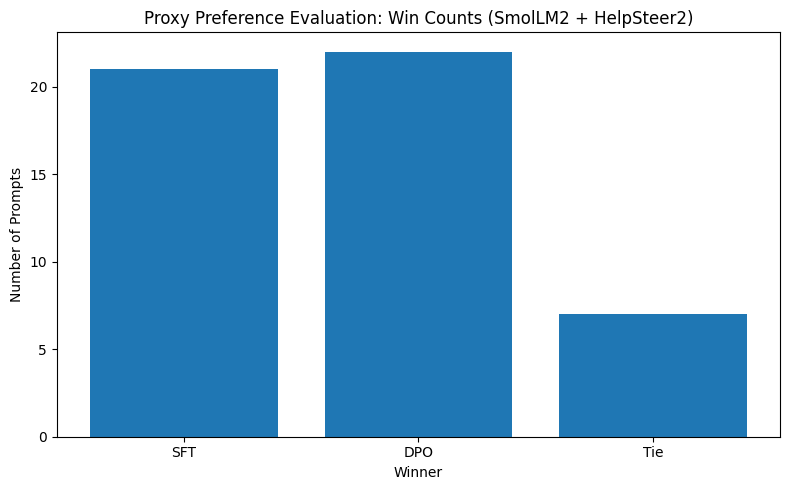

In [ ]:
import matplotlib.pyplot as plt

win_counts = df["winner"].value_counts()
labels = ["SFT", "DPO", "Tie"]
values = [win_counts.get("SFT", 0), win_counts.get("DPO", 0), win_counts.get("Tie", 0)]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.title("Proxy Preference Evaluation: Win Counts (SmolLM2 + HelpSteer2)")
plt.xlabel("Winner")
plt.ylabel("Number of Prompts")
plt.tight_layout()
plt.savefig("win_counts_smollm.png", dpi=300)
plt.show()

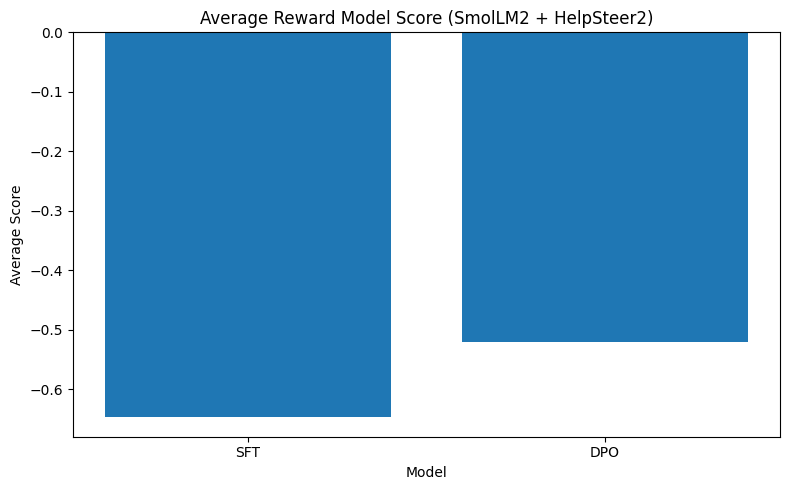

In [ ]:
avg_scores = [df["sft_score"].mean(), df["dpo_score"].mean()]
labels = ["SFT", "DPO"]

plt.figure(figsize=(8, 5))
plt.bar(labels, avg_scores)
plt.title("Average Reward Model Score (SmolLM2 + HelpSteer2)")
plt.xlabel("Model")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("avg_reward_scores_smollm.png", dpi=300)
plt.show()

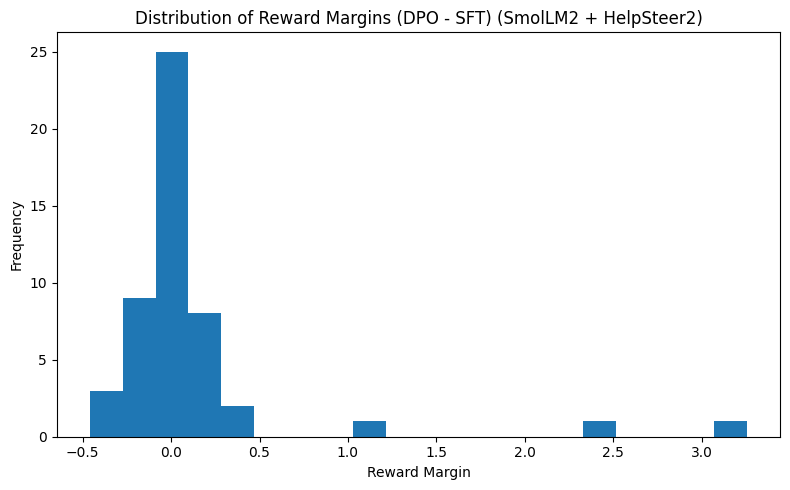

In [ ]:
df["score_margin"] = df["dpo_score"] - df["sft_score"]

plt.figure(figsize=(8, 5))
plt.hist(df["score_margin"], bins=20)
plt.title("Distribution of Reward Margins (DPO - SFT) (SmolLM2 + HelpSteer2)")
plt.xlabel("Reward Margin")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("reward_margin_hist_smollm.png", dpi=300)
plt.show()

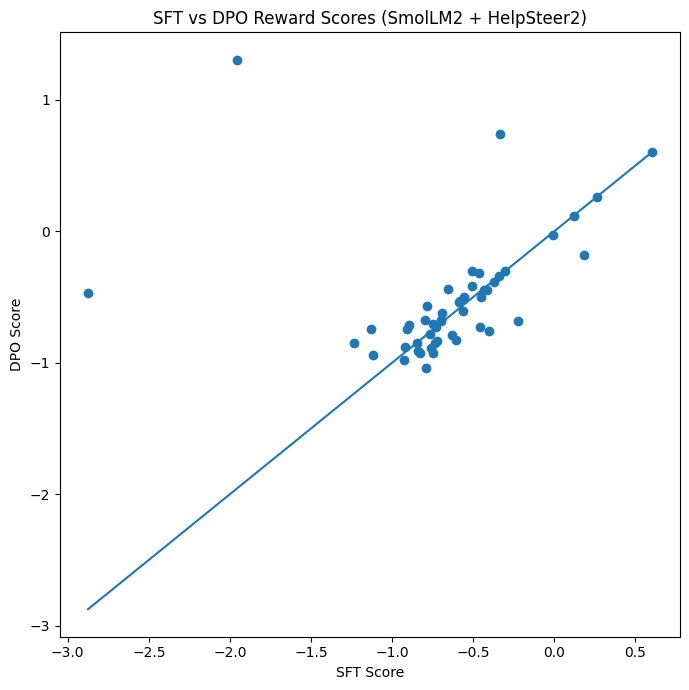

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(df["sft_score"], df["dpo_score"])
plt.plot(
    [df["sft_score"].min(), df["sft_score"].max()],
    [df["sft_score"].min(), df["sft_score"].max()]
)
plt.title("SFT vs DPO Reward Scores (SmolLM2 + HelpSteer2)")
plt.xlabel("SFT Score")
plt.ylabel("DPO Score")
plt.tight_layout()
plt.savefig("sft_vs_dpo_scatter_smollm.png", dpi=300)
plt.show()

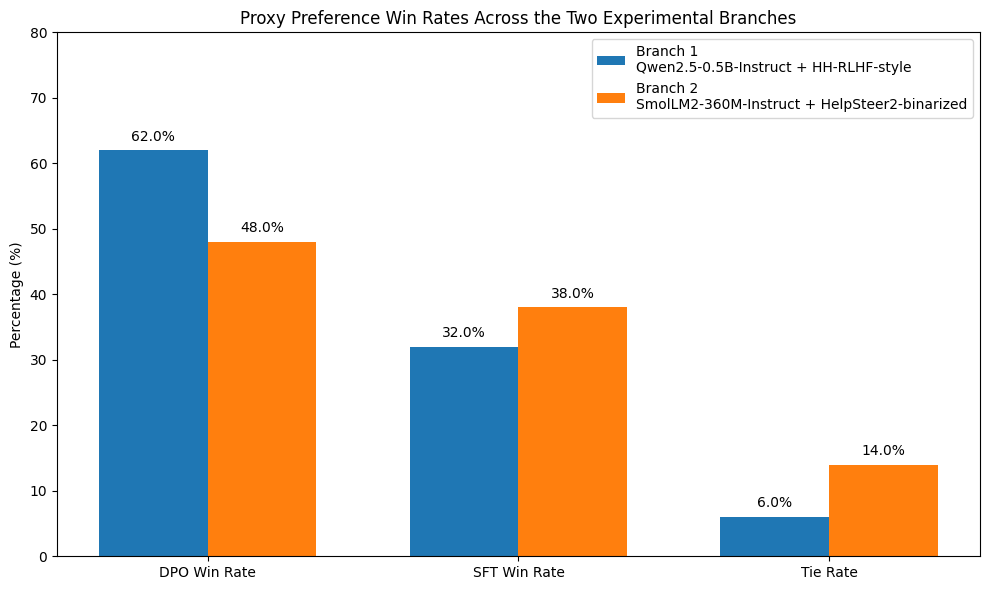

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Branch labels
branch_1_label = "Branch 1\nQwen2.5-0.5B-Instruct + HH-RLHF-style"
branch_2_label = "Branch 2\nSmolLM2-360M-Instruct + HelpSteer2-binarized"

# Metrics
categories = ["DPO Win Rate", "SFT Win Rate", "Tie Rate"]
branch_1_values = [62.0, 32.0, 6.0]
branch_2_values = [48.0, 38.0, 14.0]

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, branch_1_values, width, label=branch_1_label)
bars2 = plt.bar(x + width/2, branch_2_values, width, label=branch_2_label)

plt.xticks(x, categories)
plt.ylabel("Percentage (%)")
plt.title("Proxy Preference Win Rates Across the Two Experimental Branches")
plt.legend()
plt.ylim(0, 80)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.savefig("branch_win_rate_comparison.png", dpi=300)
plt.show()

In [ ]:
import pandas as pd
from IPython.display import display

comparison_df = pd.DataFrame({
    "Metric": [
        "DPO Win Rate (%)",
        "SFT Win Rate (%)",
        "Tie Rate (%)",
        "Average Reward Margin (DPO - SFT)"
    ],
    "Branch 1\nQwen + HH-RLHF-style": [62.0, 32.0, 6.0, 0.7789],
    "Branch 2\nSmolLM2 + HelpSteer2": [48.0, 38.0, 14.0, -0.0024],
    "Preferred Direction": ["Higher", "Lower", "Lower", "Higher"]
})

def pick_winner(row):
    b1 = row["Branch 1\nQwen + HH-RLHF-style"]
    b2 = row["Branch 2\nSmolLM2 + HelpSteer2"]
    pref = row["Preferred Direction"]

    if pref == "Higher":
        if b1 > b2:
            return "Branch 1"
        elif b2 > b1:
            return "Branch 2"
        else:
            return "Tie"
    else:  # Lower is better
        if b1 < b2:
            return "Branch 1"
        elif b2 < b1:
            return "Branch 2"
        else:
            return "Tie"

def margin(row):
    b1 = row["Branch 1\nQwen + HH-RLHF-style"]
    b2 = row["Branch 2\nSmolLM2 + HelpSteer2"]
    return round(abs(b1 - b2), 4)

def interpretation(row):
    metric = row["Metric"]
    winner = row["Winner"]
    diff = row["Difference"]

    if metric == "DPO Win Rate (%)":
        return f"{winner} shows stronger DPO advantage by {diff:.1f} points."
    elif metric == "SFT Win Rate (%)":
        return f"{winner} preserves stronger baseline performance by {diff:.1f} points."
    elif metric == "Tie Rate (%)":
        return f"{winner} is more decisive, with {diff:.1f} points fewer ties."
    elif metric == "Average Reward Margin (DPO - SFT)":
        return f"{winner} shows stronger DPO improvement over SFT by {diff:.4f}."
    return ""

comparison_df["Winner"] = comparison_df.apply(pick_winner, axis=1)
comparison_df["Difference"] = comparison_df.apply(margin, axis=1)
comparison_df["Interpretation"] = comparison_df.apply(interpretation, axis=1)

display(comparison_df)
comparison_df.to_csv("branch_comparison_matrix.csv", index=False)

,Metric,Branch 1\nQwen + HH-RLHF-style,Branch 2\nSmolLM2 + HelpSteer2,Preferred Direction,Winner,Difference,Interpretation
0,DPO Win Rate (%),62.0000,48.0000,Higher,Branch 1,14.0000,Branch 1 shows stronger DPO advantage by 14.0 ...
1,SFT Win Rate (%),32.0000,38.0000,Lower,Branch 1,6.0000,Branch 1 preserves stronger baseline performan...
2,Tie Rate (%),6.0000,14.0000,Lower,Branch 1,8.0000,"Branch 1 is more decisive, with 8.0 points few..."
3,Average Reward Margin (DPO - SFT),0.7789,-0.0024,Higher,Branch 1,0.7813,Branch 1 shows stronger DPO improvement over S...


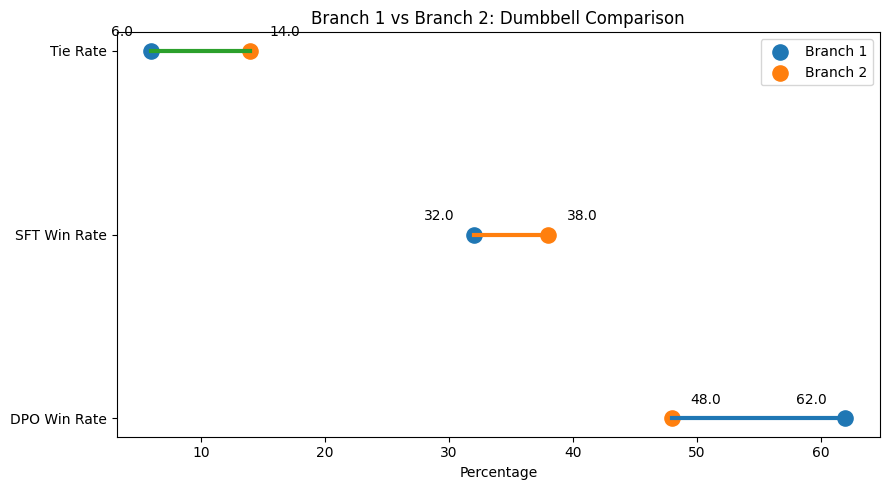

In [43]:
import matplotlib.pyplot as plt

metrics = ["DPO Win Rate", "SFT Win Rate", "Tie Rate"]
branch1_vals = [62.0, 32.0, 6.0]
branch2_vals = [48.0, 38.0, 14.0]

y_pos = range(len(metrics))

plt.figure(figsize=(9, 5))

for i in range(len(metrics)):
    plt.plot([branch1_vals[i], branch2_vals[i]], [i, i], linewidth=3)

plt.scatter(branch1_vals, y_pos, s=120, label="Branch 1")
plt.scatter(branch2_vals, y_pos, s=120, label="Branch 2")

for i, v in enumerate(branch1_vals):
    plt.text(v - 1.5, i + 0.08, f"{v:.1f}", ha="right")
for i, v in enumerate(branch2_vals):
    plt.text(v + 1.5, i + 0.08, f"{v:.1f}", ha="left")

plt.yticks(y_pos, metrics)
plt.xlabel("Percentage")
plt.title("Branch 1 vs Branch 2: Dumbbell Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("branch_dumbbell_comparison.png", dpi=300)
plt.show()

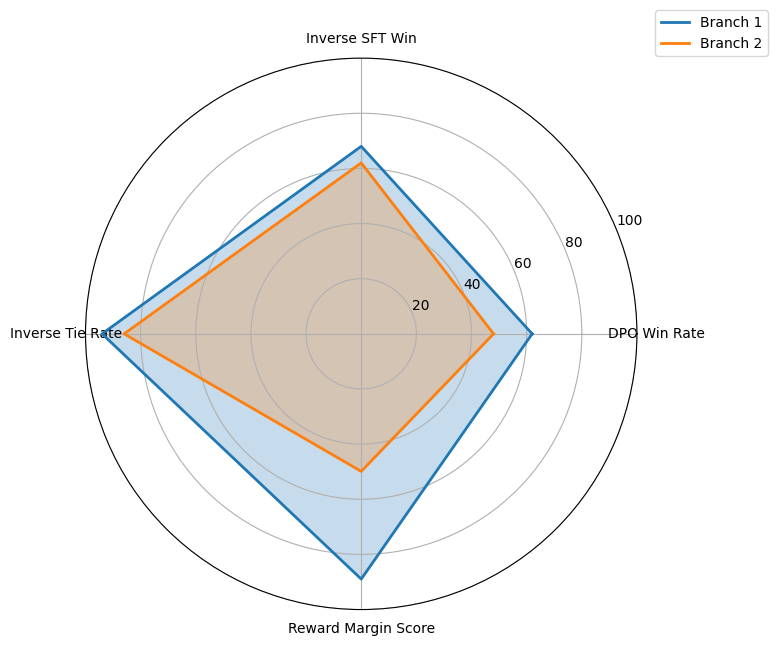

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Raw metrics
branch1 = {
    "DPO Win Rate": 62.0,
    "SFT Win Rate": 32.0,   # lower is better for branch strength
    "Tie Rate": 6.0,        # lower is better
    "Reward Margin": 0.7789
}

branch2 = {
    "DPO Win Rate": 48.0,
    "SFT Win Rate": 38.0,
    "Tie Rate": 14.0,
    "Reward Margin": -0.0024
}

# Convert everything so "higher is better"
branch1_scores = [
    branch1["DPO Win Rate"],          # higher better
    100 - branch1["SFT Win Rate"],    # lower better -> convert
    100 - branch1["Tie Rate"],        # lower better -> convert
    (branch1["Reward Margin"] + 1) * 50   # map roughly from [-1, 1] to [0, 100]
]

branch2_scores = [
    branch2["DPO Win Rate"],
    100 - branch2["SFT Win Rate"],
    100 - branch2["Tie Rate"],
    (branch2["Reward Margin"] + 1) * 50
]

labels = [
    "DPO Win Rate",
    "Inverse SFT Win",
    "Inverse Tie Rate",
    "Reward Margin Score"
]

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

branch1_scores += branch1_scores[:1]
branch2_scores += branch2_scores[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, branch1_scores, linewidth=2, label="Branch 1")
ax.fill(angles, branch1_scores, alpha=0.25)

ax.plot(angles, branch2_scores, linewidth=2, label="Branch 2")
ax.fill(angles, branch2_scores, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 100)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.tight_layout()
plt.savefig("branch_radar_comparison.png", dpi=300)
plt.show()